<a href="https://colab.research.google.com/github/timur262007/first-project/blob/main/%D1%82%D0%B1%D0%B0%D0%BD%D0%BA_%D0%BF%D1%80%D0%BE%D0%B5%D0%BA%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/kicksharing.csv')

In [ ]:
df.describe()

,order_rk,party_rk,age,minute_cost,activation_cost,hold_amount,distance_km,book_time_zone_cd,nominal_price_rub_amt,loyalty_accrual_rub_amt,loyalty_accrual_bns_amt
count,1.940640e+05,1.940640e+05,194064.000000,194064.000000,194064.000000,194064.000000,194064.000000,194064.000000,194063.000000,179431.000000,10845.000000
mean,2.895188e+08,6.001214e+08,31.532500,7.294166,42.636707,299.986293,3.888046,3.530670,128.040871,38.031433,133.322229
std,3.827682e+07,3.311344e+08,9.427275,1.289995,11.919451,1.856927,167.964033,1.199095,102.188984,78.078222,622.682465
min,2.526112e+08,1.471700e+04,12.000000,1.500000,0.000000,80.000000,0.000000,1.000000,0.000000,-33.520000,1.000000
25%,2.618156e+08,2.974671e+08,24.000000,6.490000,30.000000,300.000000,0.941387,3.000000,80.960000,11.290000,43.000000
50%,2.704388e+08,6.112704e+08,31.000000,7.490000,50.000000,300.000000,1.731615,3.000000,103.940000,18.740000,62.000000
75%,3.432699e+08,8.651101e+08,37.000000,8.230000,50.000000,300.000000,3.066902,3.000000,142.100000,35.490000,81.000000
max,3.562528e+08,1.301075e+09,94.000000,19.990000,50.000000,500.000000,56012.640308,12.000000,4362.830000,3185.000000,55429.360970


Text(0.5, 1.0, 'Пропущенные значения')

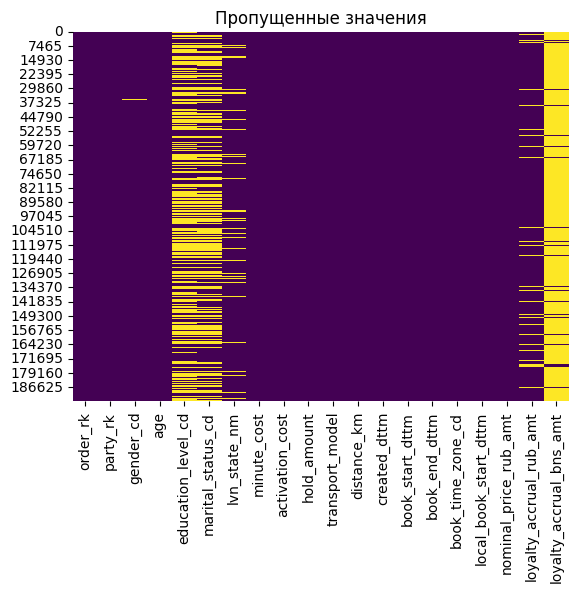

In [ ]:
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Пропущенные значения")

Text(0.5, 1.0, 'Распределение суммы за поездку')

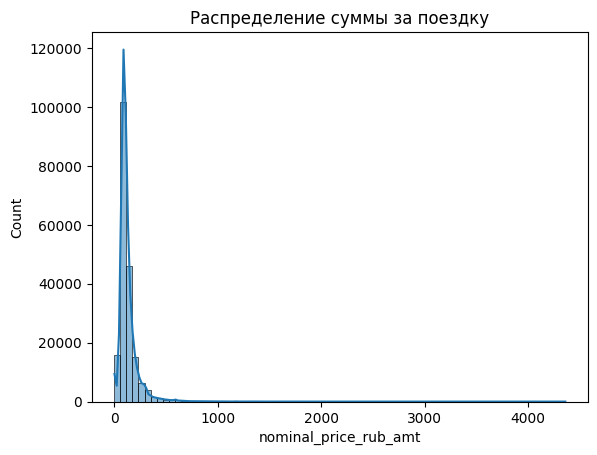

In [ ]:
sns.histplot(df["nominal_price_rub_amt"], bins=75, kde=True)
plt.title('Распределение суммы за поездку')

In [ ]:
df['gender_cd'].value_counts()

,count
gender_cd,
M,164139
F,28468


In [ ]:
164139 / 	28468

5.765736967823521

<Axes: xlabel='transport_model', ylabel='count'>

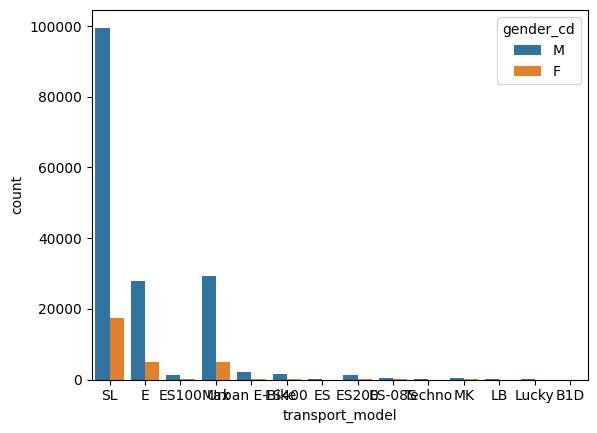

In [ ]:
sns.countplot(df, x='transport_model', hue='gender_cd')

In [ ]:
count_of_female = df.query("gender_cd == 'F' & transport_model == 'E'")
count_of_female.shape[0]

4876

In [ ]:
count_of_male = df.query("gender_cd == 'M' & transport_model == 'E'")
count_of_male.shape[0]

27950

In [122]:
df['nominal_price_rub_amt'].quantile(0.75)

np.float64(142.1)

In [ ]:
bins = [0, 18, 35, 60, 100]
labels = ['Ребенок', 'Молодой', 'Средний', 'Пожилой']
df['age_category'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

<Axes: xlabel='education_level_cd', ylabel='count'>

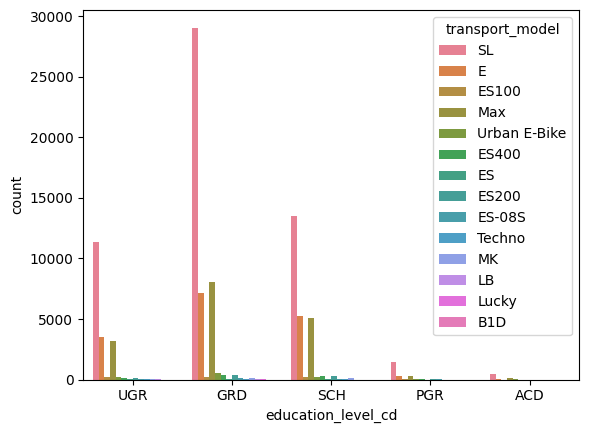

In [ ]:
sns.countplot(df, x='education_level_cd', hue='transport_model')

In [ ]:
df['round_distance'] = df['distance_km'].round(0)


In [ ]:
grd_mean = df.query("education_level_cd == 'GRD'")
grd_mean['round_distance'].mean()

np.float64(3.1547399283309807)

In [ ]:
ugr_mean = df.query("education_level_cd == 'UGR'")
ugr_mean['round_distance'].mean()

np.float64(5.894895211951645)

In [ ]:
sch_mean = df.query("education_level_cd == 'SCH'")
sch_mean['round_distance'].mean()


np.float64(5.902466278234496)

In [ ]:
pgr_mean = df.query("education_level_cd == 'PGR'")
pgr_mean['round_distance'].mean()


np.float64(3.0088845014807504)

In [ ]:
acd_mean = df.query("education_level_cd == 'ACD'")
acd_mean['round_distance'].mean()

np.float64(2.709090909090909)

Text(0.5, 1.0, 'Средняя дистанция у людей с различным образованием')

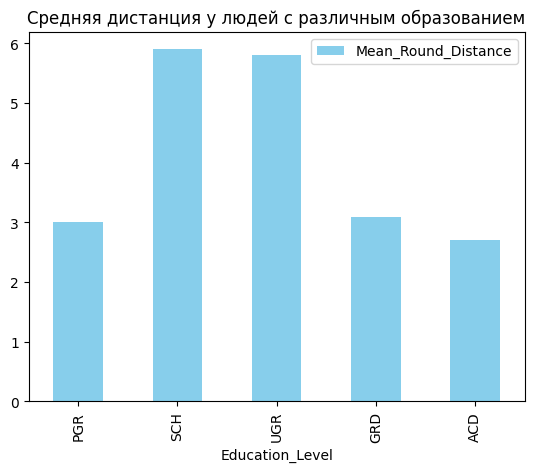

In [ ]:
data = {
    'Education_Level': ['PGR', 'SCH', 'UGR', 'GRD', 'ACD'],
    'Mean_Round_Distance': [3.0, 5.9, 5.8, 3.1, 2.7]
}

df_plot = pd.DataFrame(data)
df_plot.plot.bar(x='Education_Level', y='Mean_Round_Distance', color='skyblue')
plt.title('Средняя дистанция у людей с различным образованием')


In [124]:
bins = [0, 81, 103, 142, 500000]
labels = ['Дешевая', 'Средняя', 'Дорогая', 'Очень дорогая']
df['cost_category'] = pd.cut(df['nominal_price_rub_amt'], bins=bins, labels=labels, right=False)

Text(0.5, 1.0, 'Соотношение уровня образования и стоимости поездки')

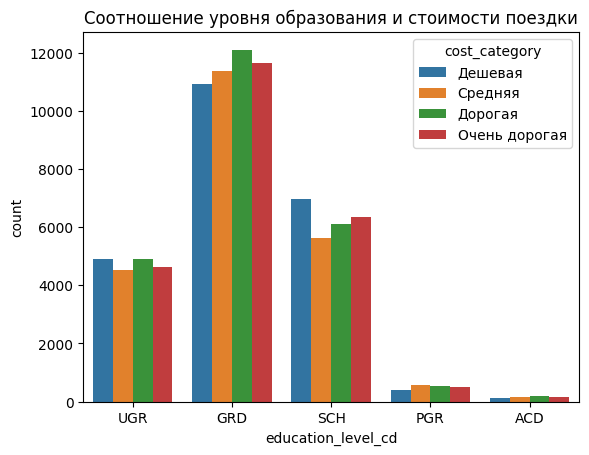

In [125]:
sns.countplot(df, x='education_level_cd', hue='cost_category')
plt.title('Соотношение уровня образования и стоимости поездки')

In [ ]:
df['education_level_cd'].value_counts()

,count
education_level_cd,
GRD,46045
SCH,25058
UGR,18943
PGR,2026
ACD,660


In [10]:
tumen = df.query("lvn_state_nm == 'ТЮМЕНСКАЯ ОБЛ'")
tumen['distance_km'].mean()

np.float64(3.1851874910251707)

In [11]:
moskva = df.query("lvn_state_nm == 'МОСКОВСКАЯ ОБЛ'")
moskva['distance_km'].mean()

np.float64(4.388346120196733)

In [12]:
nsk = df.query("lvn_state_nm == 'НОВОСИБИРСКАЯ ОБЛ'")
nsk['distance_km'].mean()

np.float64(1.977571660659946)

In [24]:
df['book_start_dttm'] = pd.to_datetime(df['book_start_dttm'])

df['час'] = df['book_start_dttm'].dt.hour
msk = df.query("lvn_state_nm == 'Г МОСКВА'")

Text(0.5, 1.0, 'Начало поездок на самокате в Москве среди мужчин и женщин')

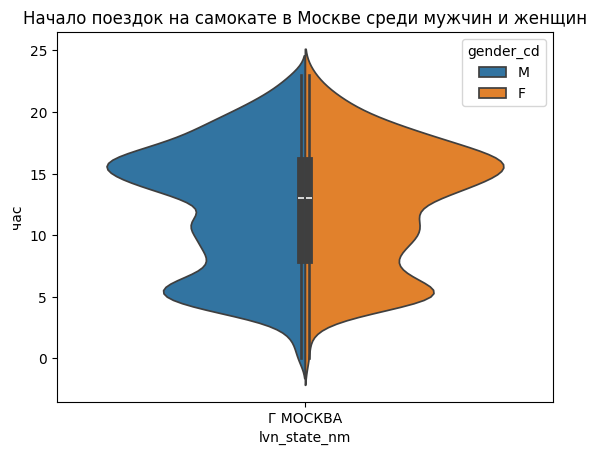

In [27]:
sns.violinplot(msk, x="lvn_state_nm", y="час", hue="gender_cd", split=True)
plt.title('Начало поездок на самокате в Москве среди мужчин и женщин')

Text(0.5, 1.0, 'Количество заказов в течение дня в Москве')

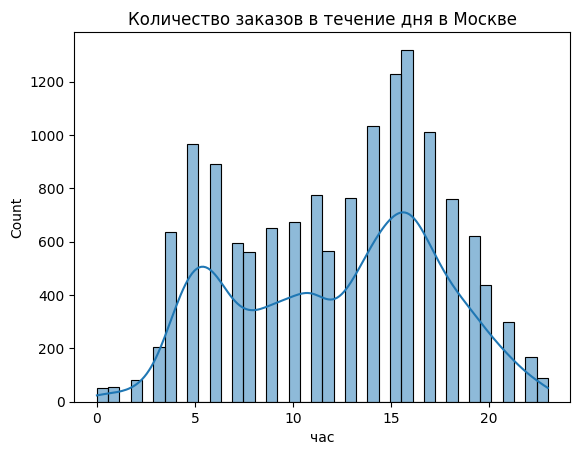

In [29]:
sns.histplot(msk["час"], bins=40, kde=True)
plt.title('Количество заказов в течение дня в Москве')

In [31]:
df['order_rk'].count()

np.int64(63069)